# **#Avocado Regression**

In [1]:
import pandas as pd

df = pd.read_csv('/content/avocado.csv')
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [2]:
!pip install pycaret
!pip install markupsafe==2.0.1
!pip jinja2

  Using cached MarkupSafe-3.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.0 kB)
Using cached MarkupSafe-3.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (23 kB)
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 2.0.1
    Uninstalling MarkupSafe-2.0.1:
      Successfully uninstalled MarkupSafe-2.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == 

In [3]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pycaret
import warnings
import jinja2

from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import *
from pycaret.regression import *

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

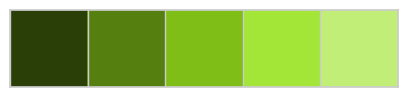

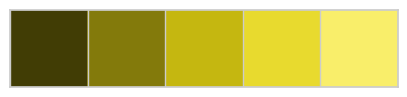

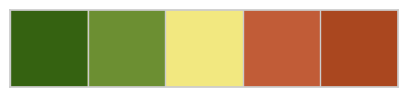

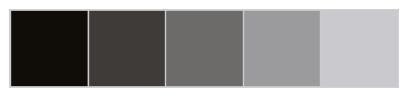

In [4]:
olive_grad = ['#2A3F07', '#557F0F', '#7FBE17', '#A4E637', '#C1EE76']
yellow_grad = ['#413D05', '#837A0B', '#C5B710', '#E8DA2E', '#F9EE6A']
color_mix = ['#356211', '#6C8F32', '#F2E880', '#C15C37', '#AA471F']
black_grad = ['#100C07', '#3E3B39', '#6D6A6A', '#9B9A9C', '#CAC9CD']

sns.palplot(olive_grad)
sns.palplot(yellow_grad)
sns.palplot(color_mix)
sns.palplot(black_grad)

In [5]:
ds = pd.read_csv('/content/avocado.csv')
ds.head().style\
    .background_gradient(cmap='Greens')\
    .set_properties(**{'font-family': 'Segoe UI'})\
    .hide(axis='index')

Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.330000,64236.620000,1036.740000,54454.850000,48.160000,8696.870000,8603.620000,93.250000,0.000000,conventional,2015,Albany
1,2015-12-20,1.350000,54876.980000,674.280000,44638.810000,58.330000,9505.560000,9408.070000,97.490000,0.000000,conventional,2015,Albany
2,2015-12-13,0.930000,118220.220000,794.700000,109149.670000,130.500000,8145.350000,8042.210000,103.140000,0.000000,conventional,2015,Albany
3,2015-12-06,1.080000,78992.150000,1132.000000,71976.410000,72.580000,5811.160000,5677.400000,133.760000,0.000000,conventional,2015,Albany
4,2015-11-29,1.280000,51039.600000,941.480000,43838.390000,75.780000,6183.950000,5986.260000,197.690000,0.000000,conventional,2015,Albany


In [6]:
print('\033[92m\033[1m'+'.: Imported Dataset Info :.'+'\033[0m')
print('\033[92m*' * 30+'\033[0m')
print('Total Rows:'+'\033[92m\033[1m', ds.shape[0])
print('\033[0m'+'Total Columns:'+'\033[92m\033[1m', ds.shape[1])
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
print('\n')

print('\033[92m\033[1m'+'.: Dataset Details :.'+'\033[0m')
print('\033[0m\033[92m'+'*' * 30+'\033[0m')
ds.info(memory_usage = False)

.: Imported Dataset Info :.
******************************
Total Rows: 18249
Total Columns: 14
******************************


.: Dataset Details :.
******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), in

****************************************
.: Total Avocado based on each Type :.
****************************************


,count
type,
conventional,9126
organic,9123


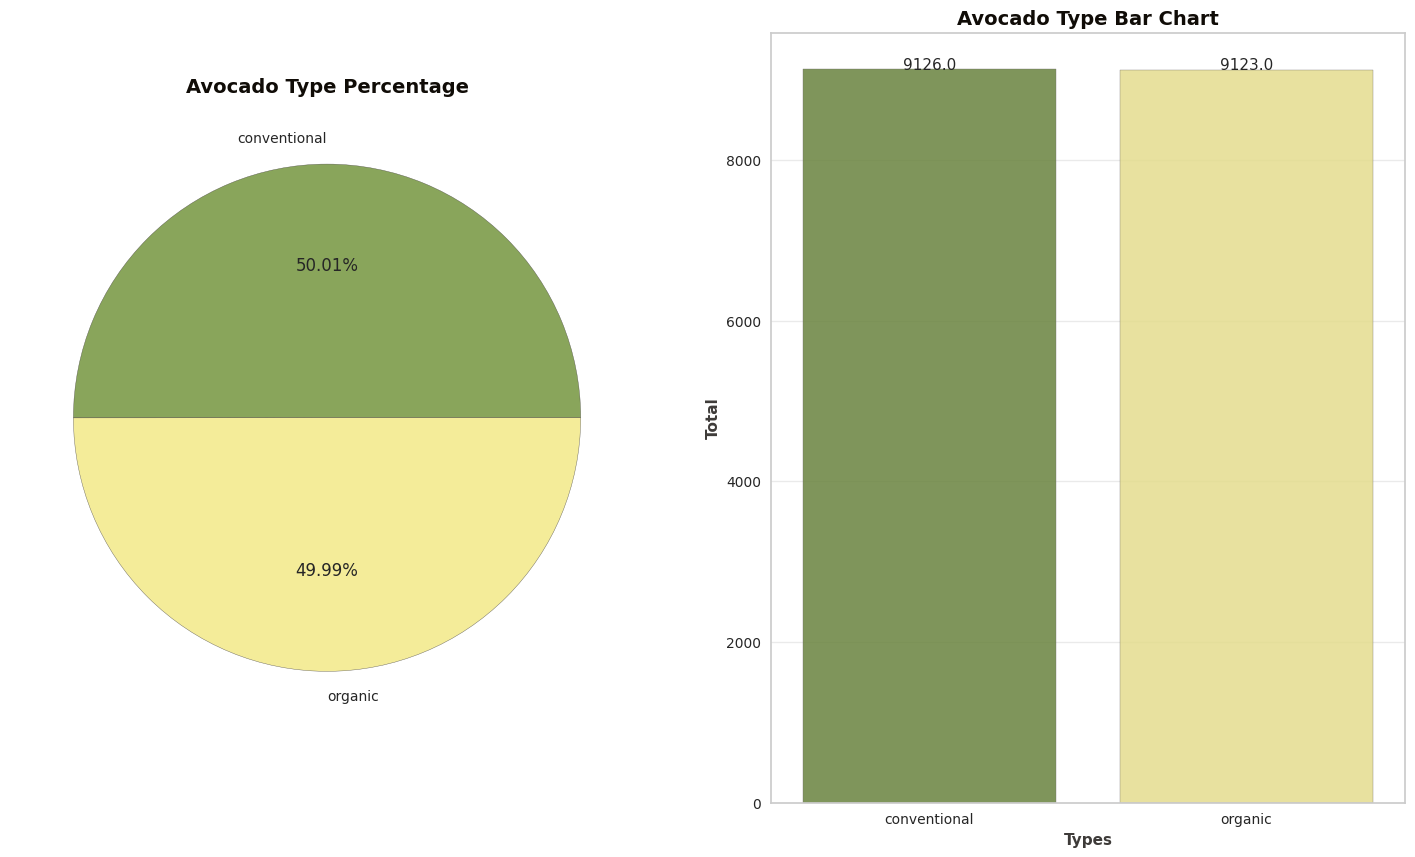

In [7]:
colors = color_mix[1:3]
labels = ds['type'].dropna().unique()
order = ds['type'].value_counts().index

plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
plt.title('Avocado Type Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
plt.pie(ds['type'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

countplt = plt.subplot(1, 2, 2)
plt.title('Avocado Type Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'type', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,rect.get_height(), horizontalalignment = 'center',
             fontsize = 11)

plt.xlabel('Types', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

print('\033[92m'+'*' * 40)
print('\033[92m\033[1m'+'.: Total Avocado based on each Type :.'+'\033[0m')
print('\033[92m'+'*' * 40+'\033[0m')
ds.type.value_counts(dropna=False)

****************************************
.: Total Avocado based on each Type :.
****************************************


,count
type,
conventional,9126
organic,9123


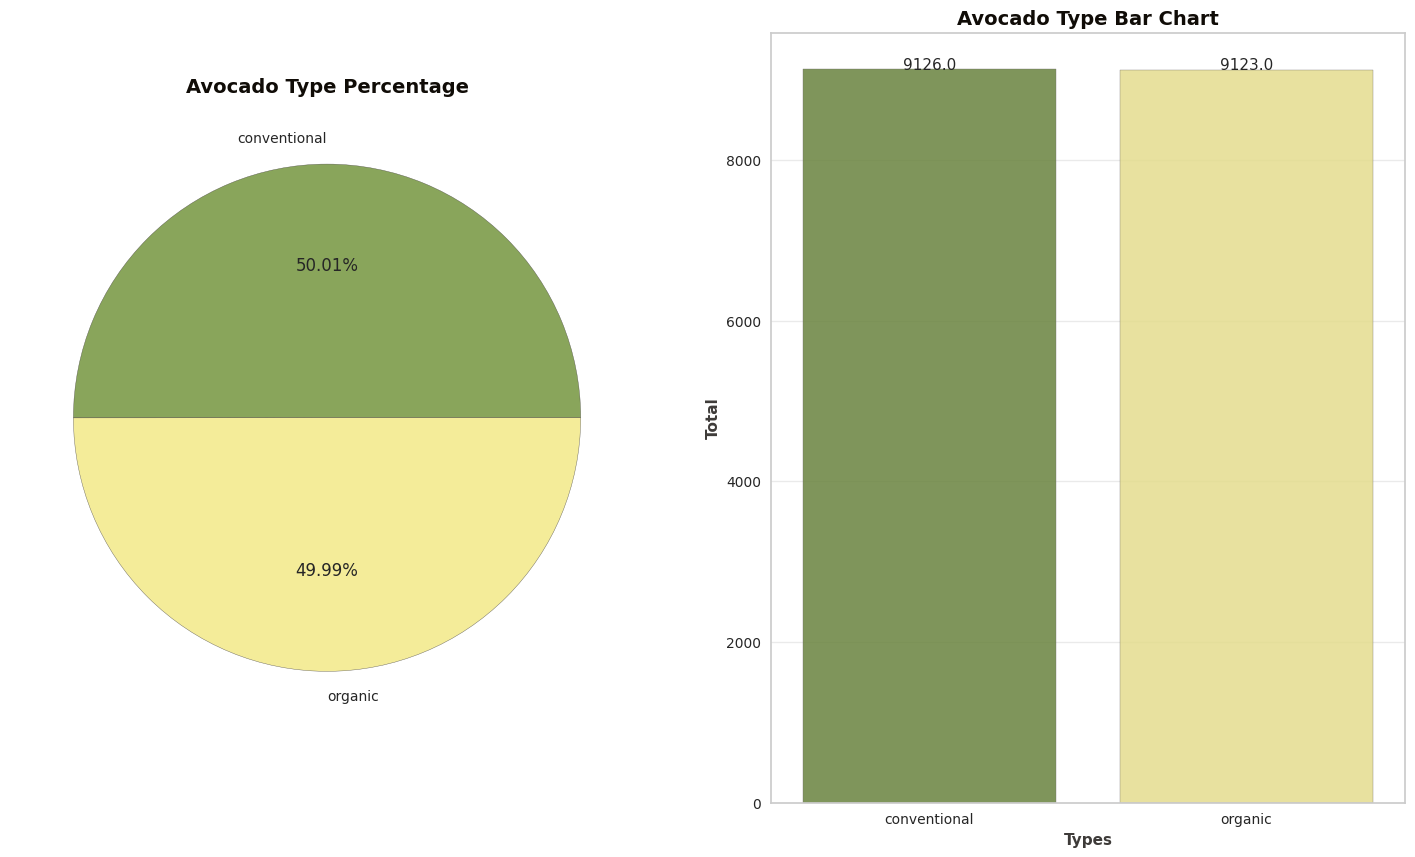

In [8]:
colors = color_mix[1:3]
labels = ds['type'].dropna().unique()
order = ds['type'].value_counts().index

plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
plt.title('Avocado Type Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
plt.pie(ds['type'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

countplt = plt.subplot(1, 2, 2)
plt.title('Avocado Type Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'type', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,rect.get_height(), horizontalalignment = 'center',
             fontsize = 11)

plt.xlabel('Types', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

print('\033[92m'+'*' * 40)
print('\033[92m\033[1m'+'.: Total Avocado based on each Type :.'+'\033[0m')
print('\033[92m'+'*' * 40+'\033[0m')
ds.type.value_counts(dropna=False)

***********************************
.: Total Avocado based on Year :.
***********************************


,count
year,
2017,5722
2016,5616
2015,5615
2018,1296


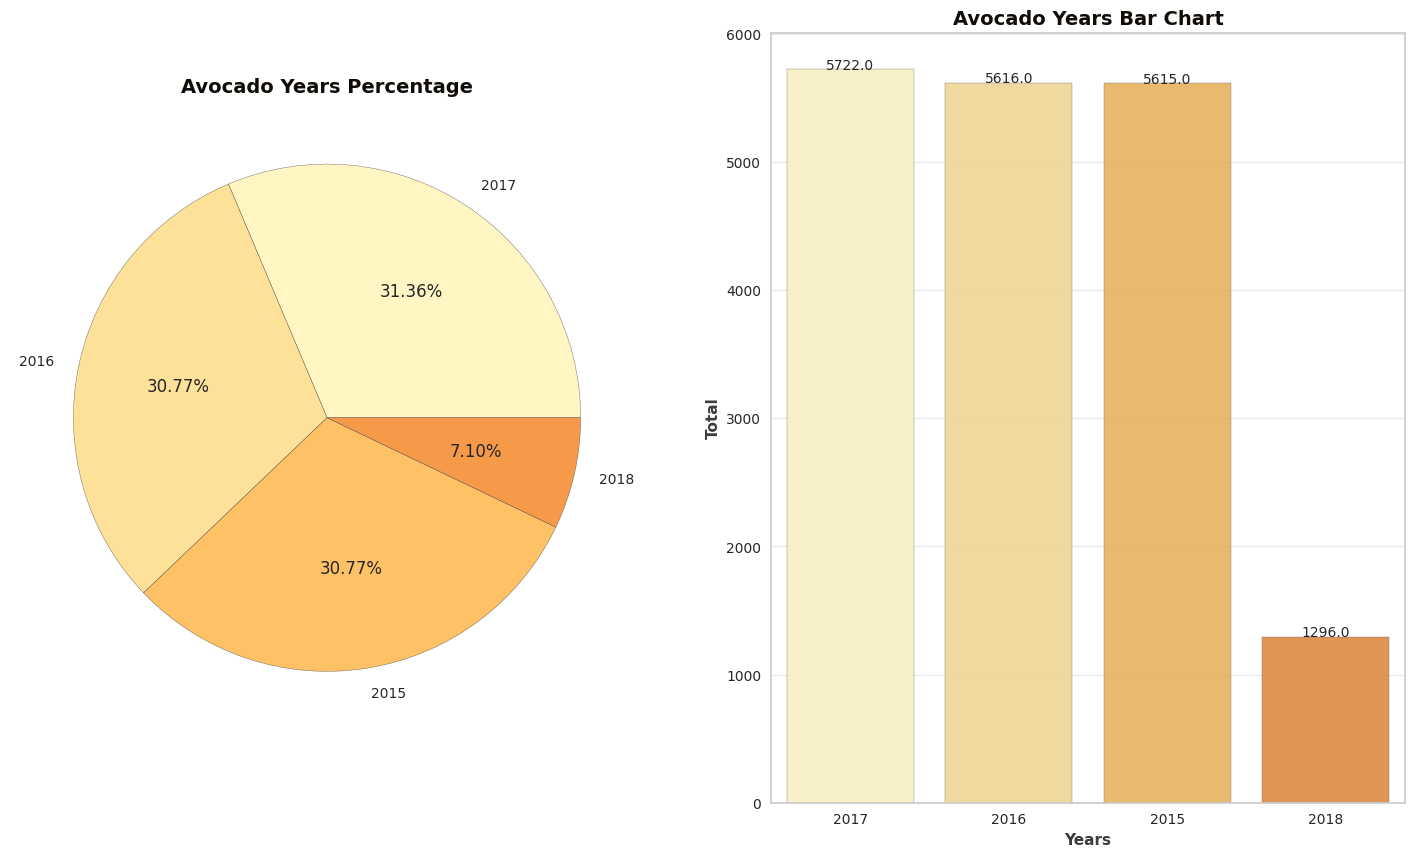

In [9]:
colors = sns.color_palette('YlOrBr')
labels = ds['year'].dropna().unique()
order = ds['year'].value_counts().index

plt.figure(figsize=(18,10))

plt.subplot(1,2,1)
plt.title('Avocado Years Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['year'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%')

countplt = plt.subplot(1,2,2)
plt.title('Avocado Years Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
ax = sns.countplot(x = 'year', data = ds, palette = colors, order = order, edgecolor = black_grad[2], alpha = 0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2, rect.get_height()+0.75,rect.get_height(), horizontalalignment = 'center',
             fontsize = 10)

plt.xlabel('Years', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total', fontweight = 'bold', fontsize = '11', fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'y', alpha = 0.4)
countplt

print('\033[92m'+'*' * 35)
print('\033[92m\033[1m'+'.: Total Avocado based on Year :.'+'\033[0m')
print('\033[92m'+'*' * 35+'\033[0m')
ds.year.value_counts(dropna=False)

In [10]:
print('\033[92m'+'*' * 38)
print('\033[92m\033[1m'+'.: Total Avocado based on Regions :.'+'\033[0m')
print('\033[92m'+'*' * 38)
ds.region.value_counts(dropna=False)

**************************************
.: Total Avocado based on Regions :.
**************************************


,count
region,
Albany,338
Sacramento,338
Northeast,338
NorthernNewEngland,338
Orlando,338
Philadelphia,338
PhoenixTucson,338
Pittsburgh,338
Plains,338


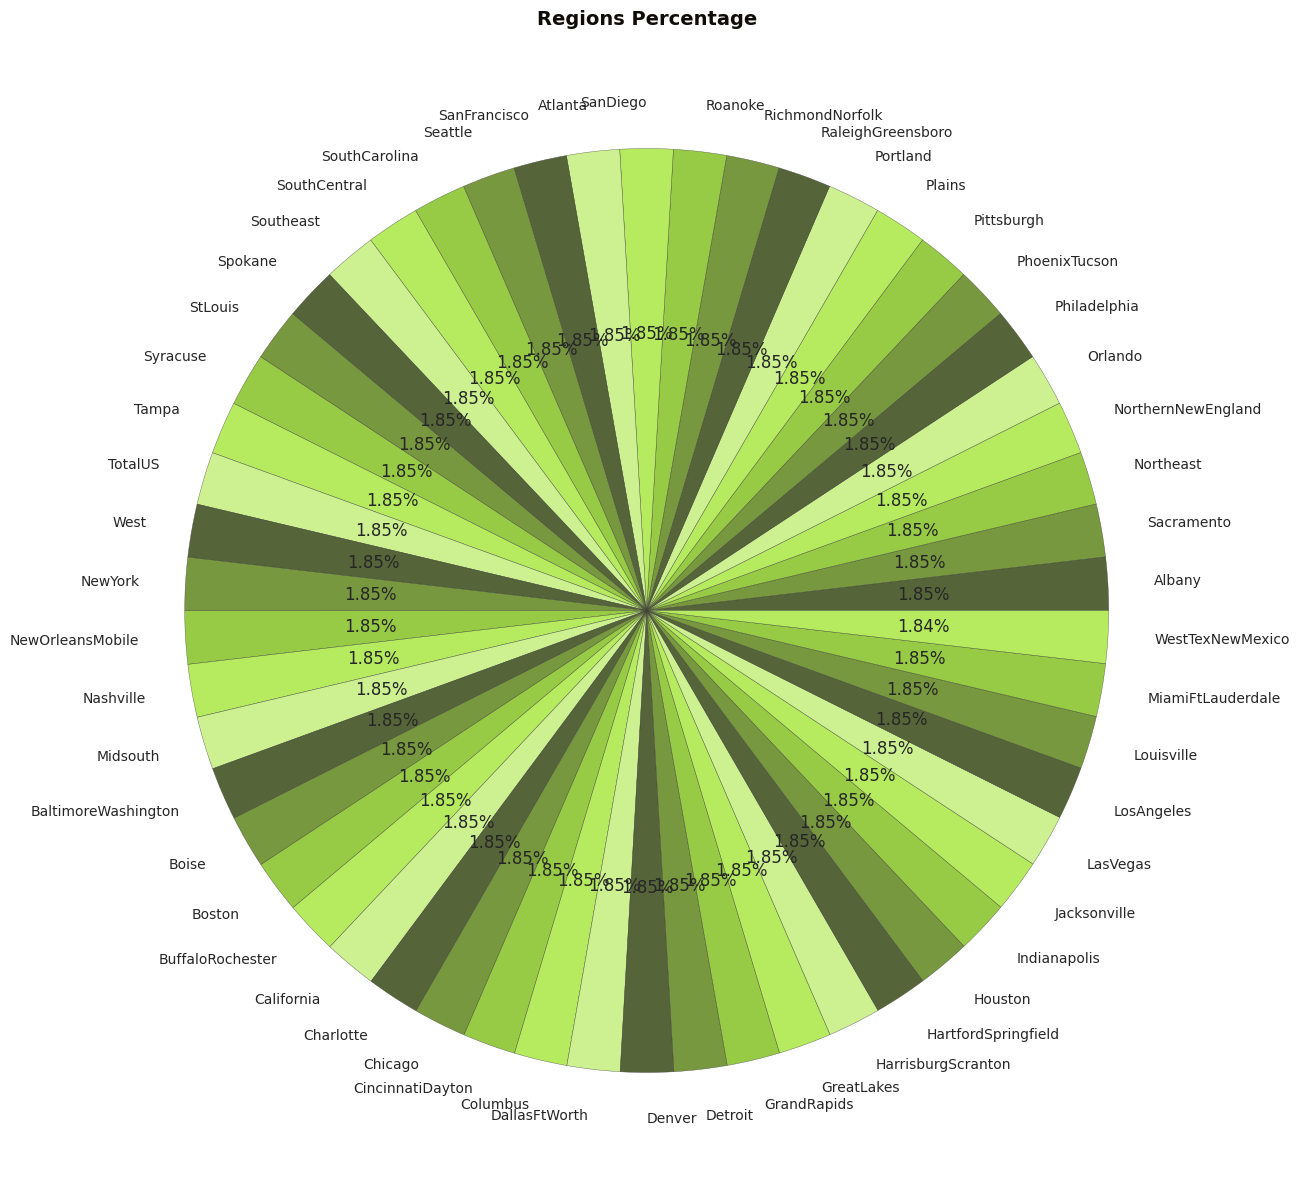

In [11]:
colors = olive_grad[0:5]
labels = ds['region'].dropna().unique()
order = ds['region'].value_counts().index

plt.figure(figsize = (15, 15))
plt.title('Regions Percentage', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
plt.pie(ds['region'].value_counts(), labels = order, colors = colors,
        wedgeprops = dict(alpha = 0.8, edgecolor = black_grad[1]), autopct = '%.2f%%');

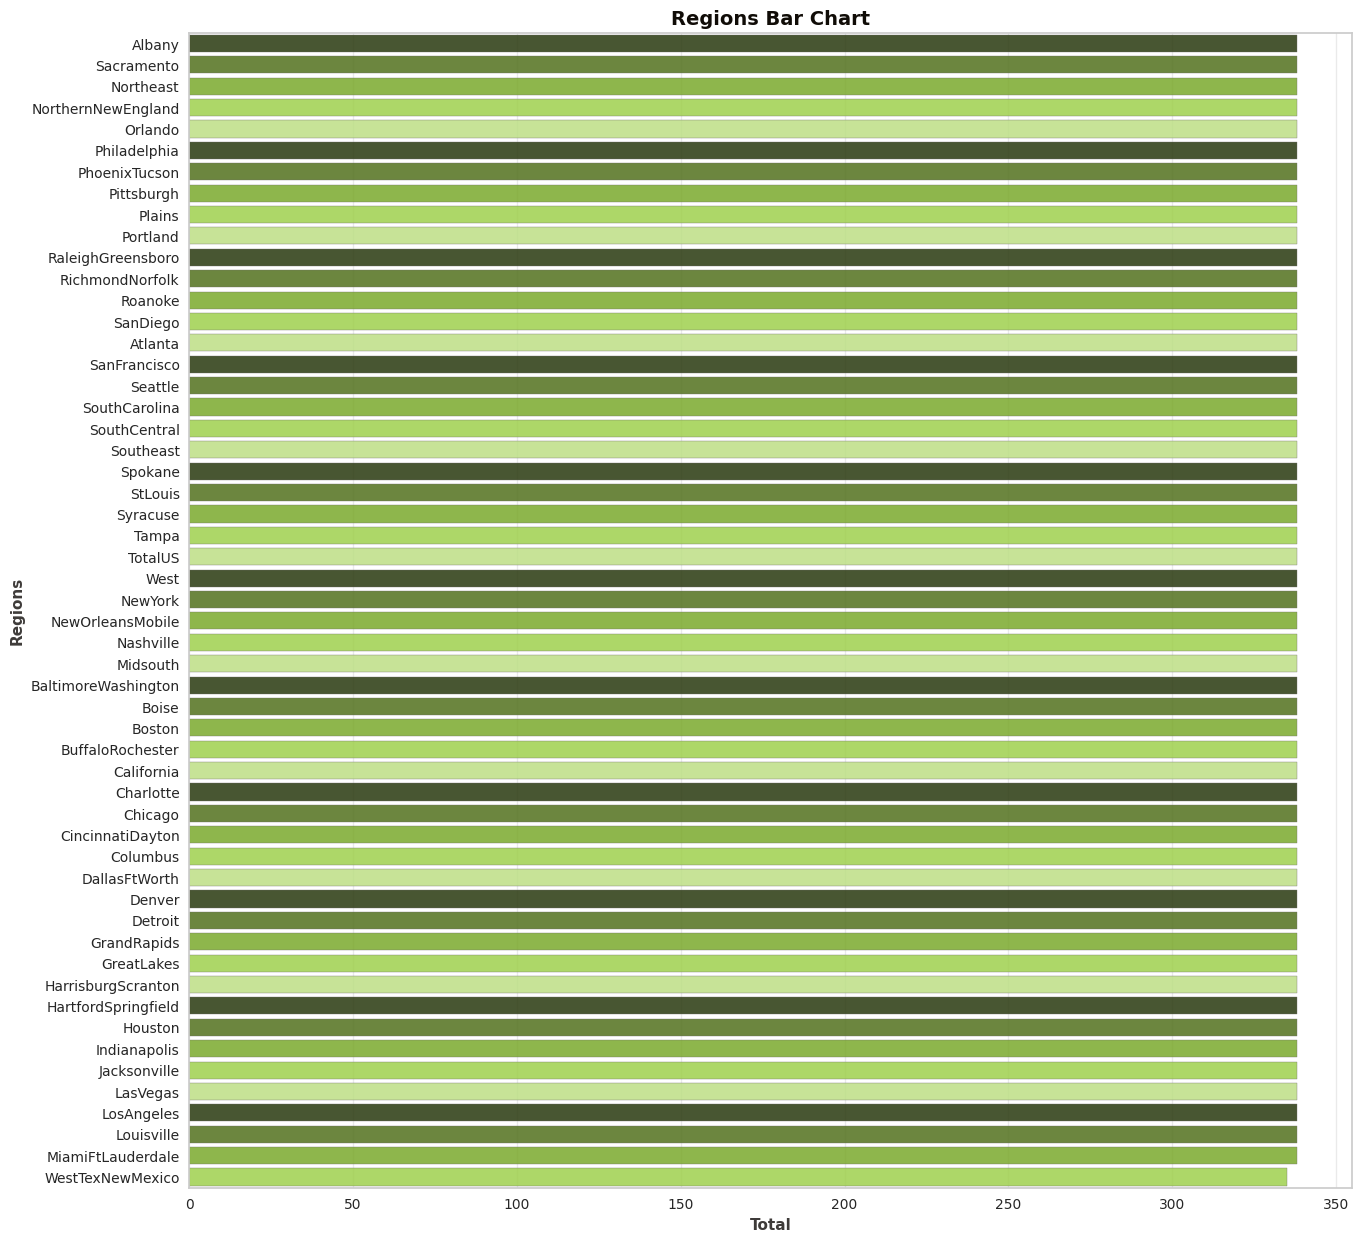

In [12]:
plt.figure(figsize = (15, 15))
plt.title('Regions Bar Chart', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif', color = black_grad[0])
sns.countplot(y = 'region', data = ds, order = order, palette = colors, edgecolor = black_grad[2], alpha = 0.85)
plt.xlabel('Total', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Regions', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.grid(axis = 'x', alpha = 0.4);

In [13]:
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].describe().T.style.background_gradient(cmap='YlOrBr').set_properties(**{'font-family': 'Segoe UI'})

,count,mean,std,min,25%,50%,75%,max
AveragePrice,18249.000000,1.405978,0.402677,0.440000,1.100000,1.370000,1.660000,3.250000
Total Volume,18249.000000,850644.013009,3453545.355399,84.560000,10838.580000,107376.760000,432962.290000,62505646.520000
4046,18249.000000,293008.424531,1264989.081763,0.000000,854.070000,8645.300000,111020.200000,22743616.170000
4225,18249.000000,295154.568356,1204120.401135,0.000000,3008.780000,29061.020000,150206.860000,20470572.610000
4770,18249.000000,22839.735993,107464.068435,0.000000,0.000000,184.990000,6243.420000,2546439.110000
Total Bags,18249.000000,239639.202060,986242.399216,0.000000,5088.640000,39743.830000,110783.370000,19373134.370000
Small Bags,18249.000000,182194.686696,746178.514962,0.000000,2849.420000,26362.820000,83337.670000,13384586.800000
Large Bags,18249.000000,54338.088145,243965.964547,0.000000,127.470000,2647.710000,22029.250000,5719096.610000
XLarge Bags,18249.000000,3106.426507,17692.894652,0.000000,0.000000,0.000000,132.500000,551693.650000


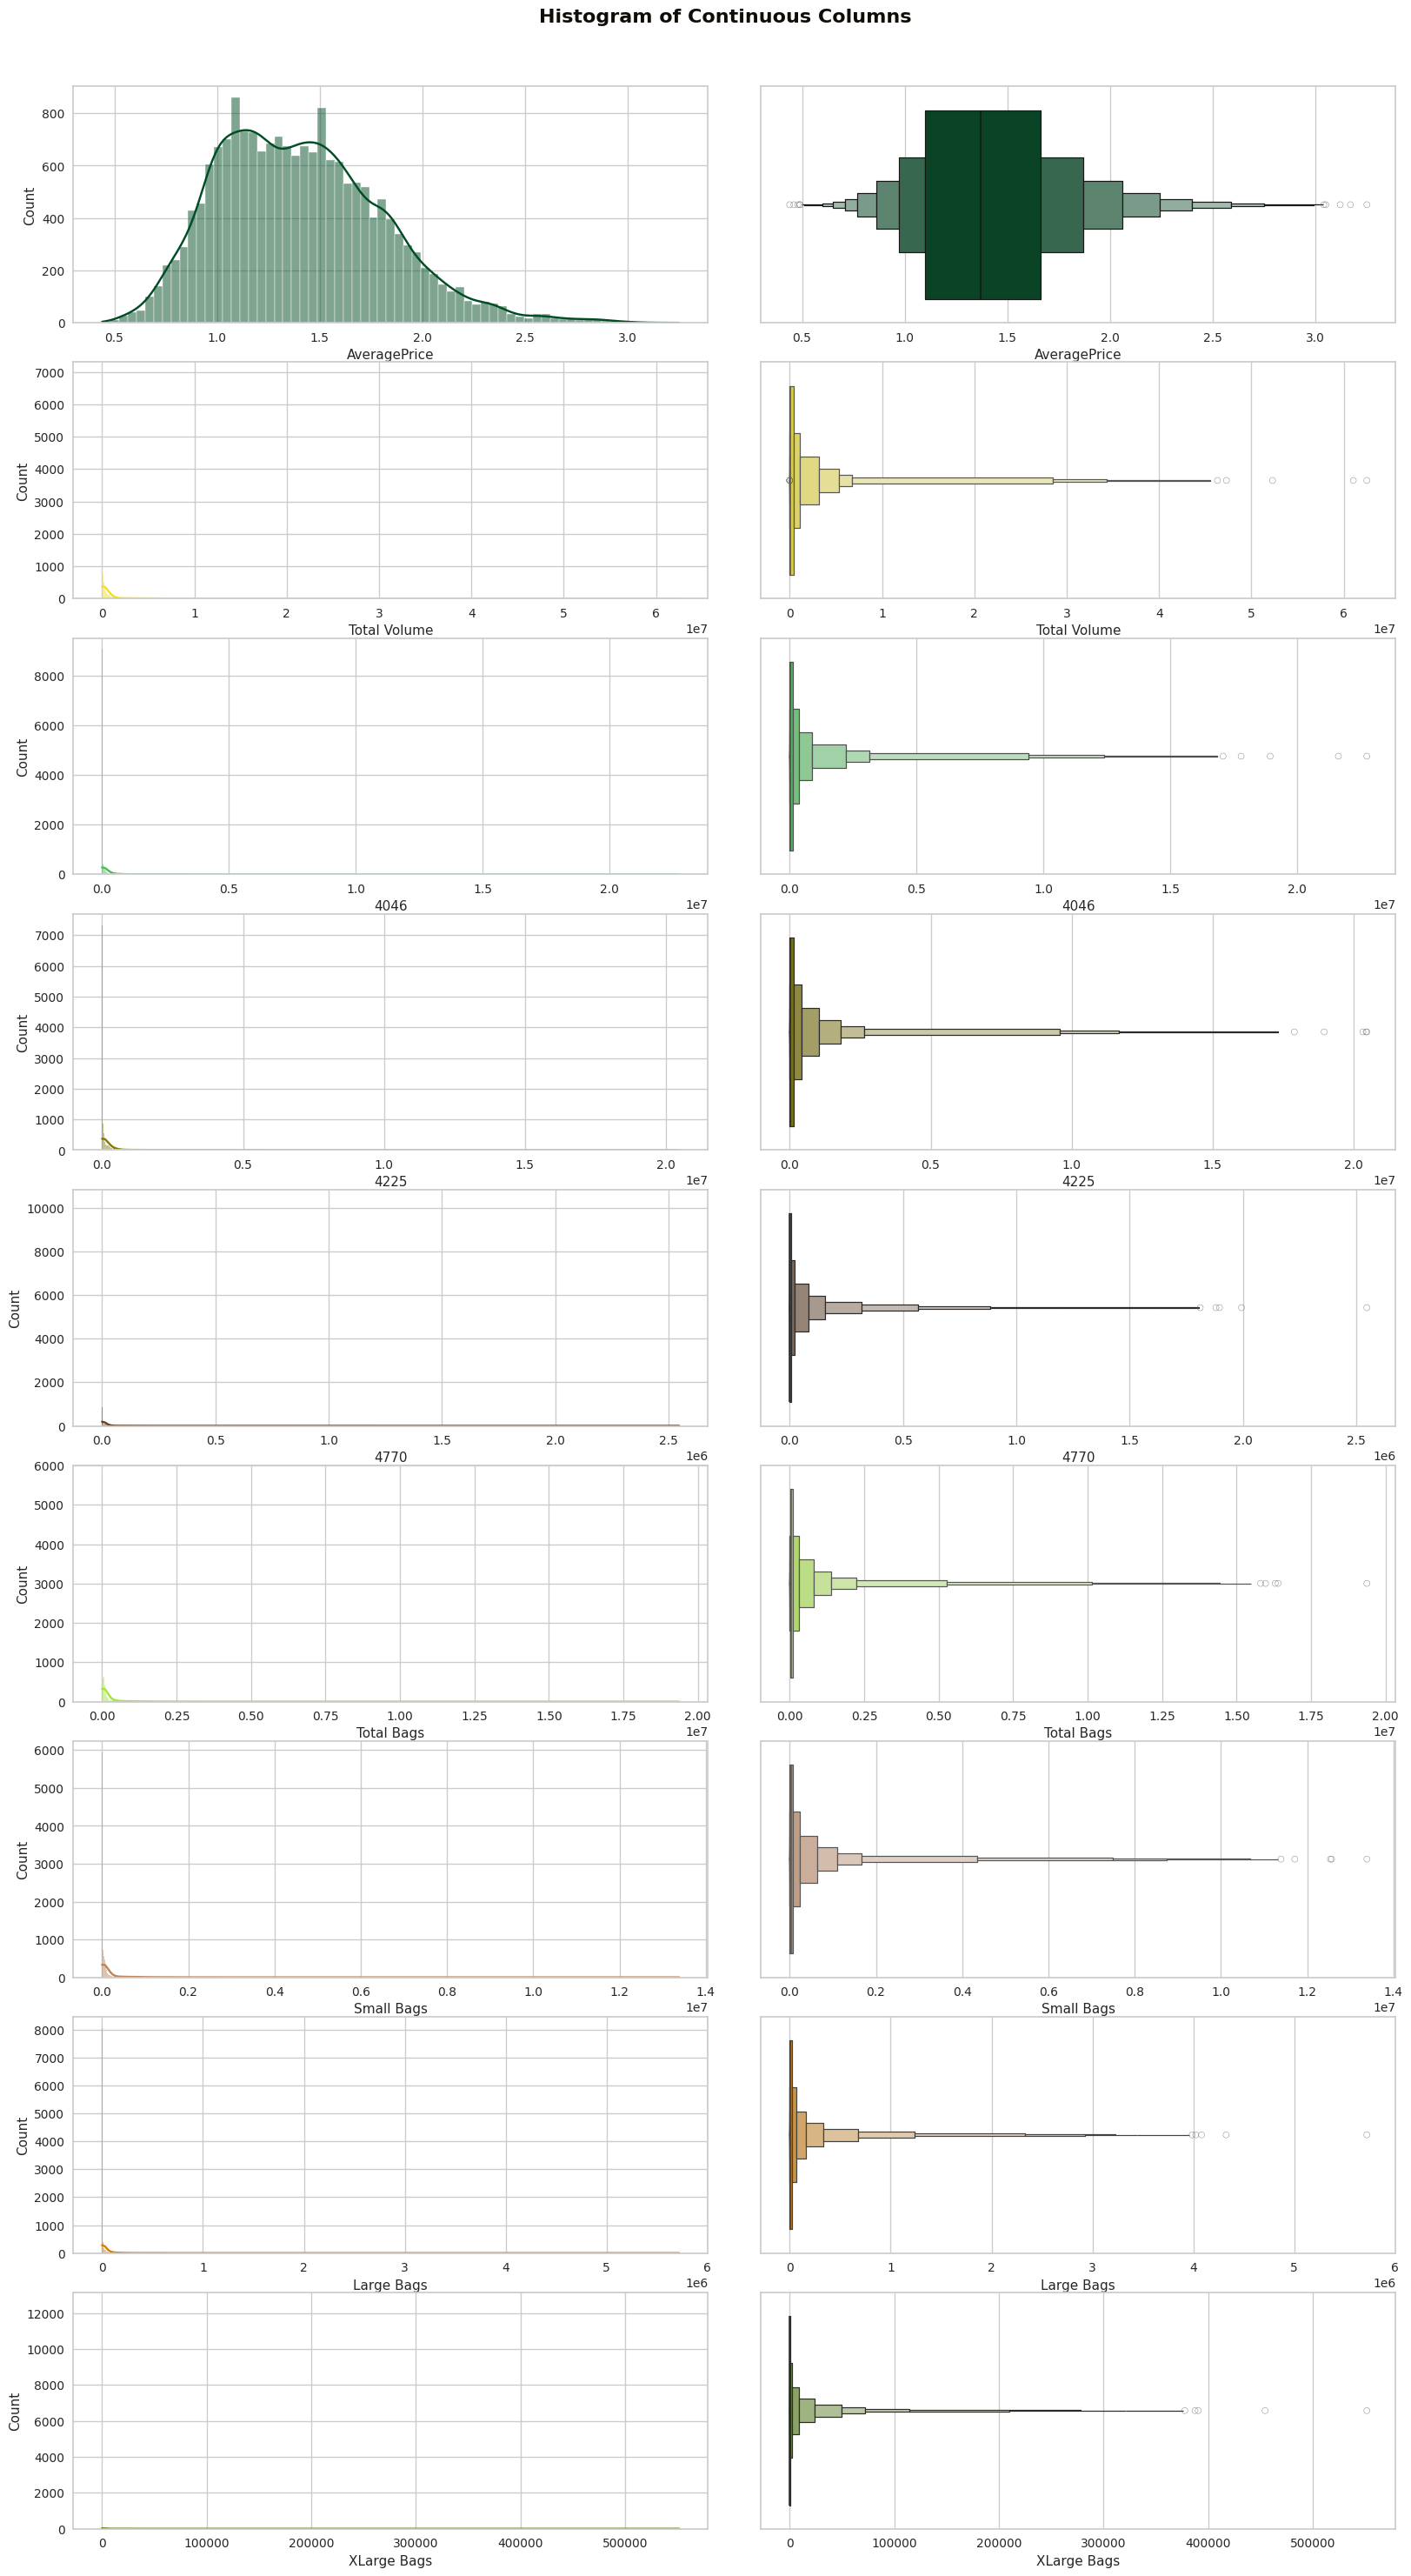

In [14]:
fig, axs = plt.subplots(9, 2, figsize = (16, 30))

fig.tight_layout()
fig.subplots_adjust(top = 0.95)
fig.suptitle('Histogram of Continuous Columns', fontweight = 'bold', fontsize = 16, fontfamily = 'sans-serif',
             color = black_grad[0])

sns.histplot(data = ds, x = 'AveragePrice', kde = True, ax = axs[0, 0], color = '#004D25')
sns.boxenplot(data = ds, x = 'AveragePrice', ax = axs[0, 1], color = '#004D25')

sns.histplot(data = ds, x = 'Total Volume', kde = True, ax = axs[1, 0], color = '#EDDE30')
sns.boxenplot(data = ds, x = 'Total Volume', ax = axs[1, 1], color = '#EDDE30')

sns.histplot(data = ds, x='4046', kde = True, ax = axs[2, 0], color = '#48BF53')
sns.boxenplot(data = ds, x = '4046', ax = axs[2, 1], color = '#48BF53')

sns.histplot(data = ds, x = '4225', kde = True, ax = axs[3, 0], color = '#837A0B')
sns.boxenplot(data = ds, x = '4225', ax = axs[3, 1], color = '#837A0B')

sns.histplot(data = ds, x = '4770', kde = True, ax = axs[4, 0], color = '#664228')
sns.boxenplot(data = ds, x = '4770', ax = axs[4, 1], color = '#664228')

sns.histplot(data = ds, x = 'Total Bags', kde = True, ax = axs[5, 0], color = '#A4E637')
sns.boxenplot(data = ds, x = 'Total Bags', ax = axs[5, 1], color = '#A4E637')

sns.histplot(data = ds, x = 'Small Bags', kde = True, ax = axs[6, 0], color = '#BF865D')
sns.boxenplot(data = ds, x = 'Small Bags', ax = axs[6, 1], color = '#BF865D')

sns.histplot(data = ds, x = 'Large Bags', kde = True, ax = axs[7, 0], color = '#D98000')
sns.boxenplot(data = ds, x = 'Large Bags', ax = axs[7, 1], color = '#D98000')

sns.histplot(data = ds, x = 'XLarge Bags', kde = True, ax = axs[8, 0], color = '#557F0F')
sns.boxenplot(data = ds, x = 'XLarge Bags', ax = axs[8, 1], color = '#557F0F');

In [15]:
print('\033[92m\033[1m'+'.: Continuous Columns Skewness :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].skew(axis = 0, skipna = True)

.: Continuous Columns Skewness :.
**********************************


,0
AveragePrice,0.580303
Total Volume,9.007687
4046,8.648220
4225,8.942466
4770,10.159396
Total Bags,9.756072
Small Bags,9.540660
Large Bags,9.796455
XLarge Bags,13.139751


In [16]:
print('\033[92m\033[1m'+'.: Continuous Columns Kurtosis :.'+'\033[0m')
print('\033[92m*' * 34+'\033[0m')
ds[['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags',
    'XLarge Bags']].kurt(axis = 0, skipna = True)

.: Continuous Columns Kurtosis :.
**********************************


,0
AveragePrice,0.325196
Total Volume,92.104458
4046,86.809113
4225,91.949022
4770,132.563441
Total Bags,112.272156
Small Bags,107.012885
Large Bags,117.999481
XLarge Bags,233.602612


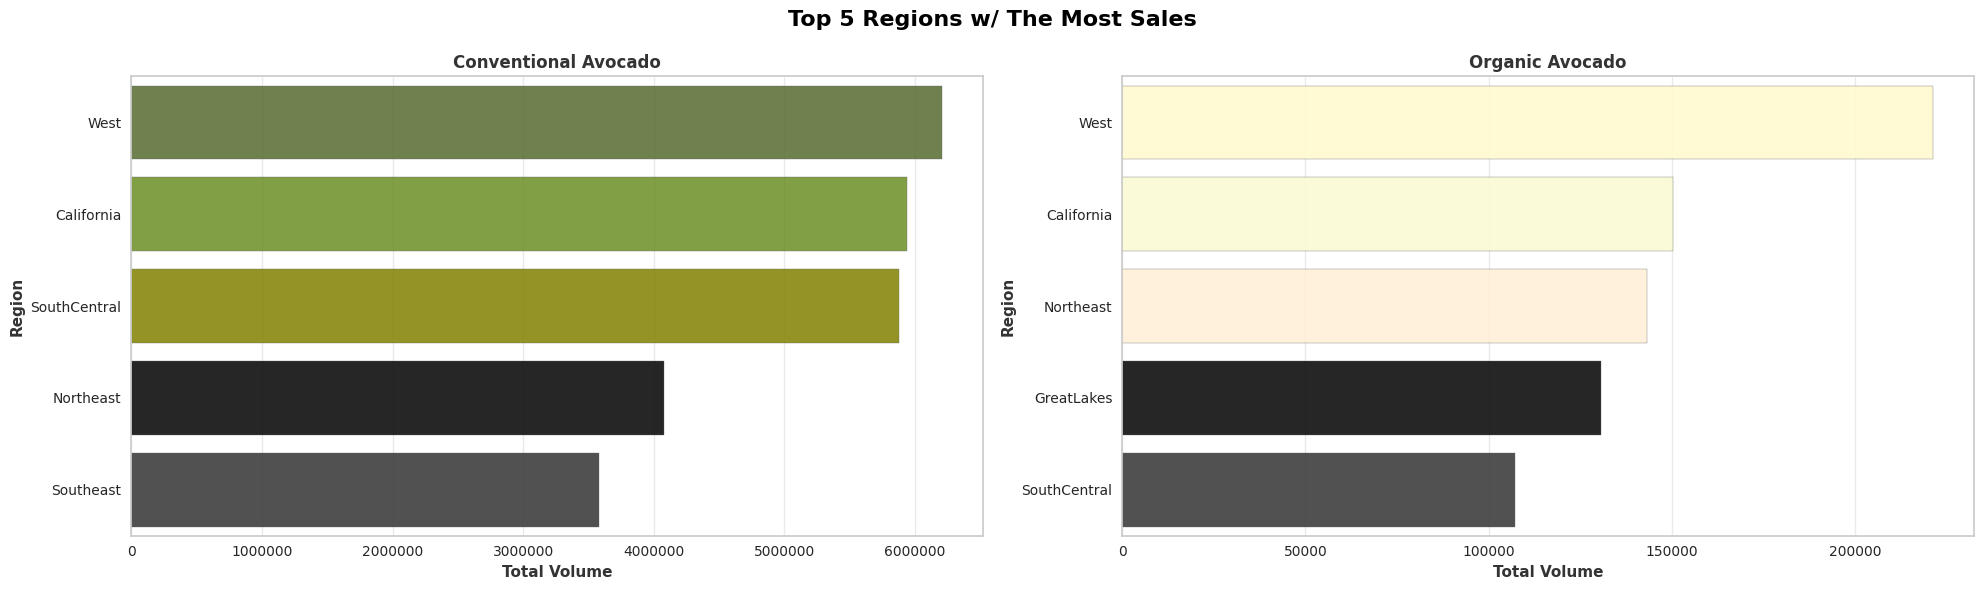

In [17]:
ds_conventional = ds[ds['type'] == 'conventional']
ds_organic = ds[ds['type'] == 'organic']

# 'TotalUS' 제외
ds_conventional = ds_conventional[ds_conventional['region'] != 'TotalUS']
ds_organic = ds_organic[ds_organic['region'] != 'TotalUS']

# 그룹별 평균 계산 후 상위 5개 추출
eda0 = ds_conventional.groupby('region').agg({'Total Volume': 'mean'}).sort_values(by='Total Volume', ascending=False).iloc[:5]
eda1 = ds_organic.groupby('region').agg({'Total Volume': 'mean'}).sort_values(by='Total Volume', ascending=False).iloc[:5]

# 팔레트 정의 (필요 시 조정)
black_grad = ['#000000', '#333333', '#666666']
olive_grad = ['#556B2F', '#6B8E23', '#808000']
yellow_grad = ['#FFFFE0', '#FFFACD', '#FAFAD2', '#FFEFD5']

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Top 5 Regions w/ The Most Sales', fontweight='heavy', fontsize=16, fontfamily='sans-serif', color=black_grad[0])

# Conventional
plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
bar_left = sns.barplot(x='Total Volume', y=eda0.index, data=eda0, palette=black_grad, edgecolor=black_grad[2], alpha=0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Total Volume', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.ylabel('Region', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.4)
plt.ticklabel_format(style='plain', axis='x')

# Organic
plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
bar_right = sns.barplot(x='Total Volume', y=eda1.index, data=eda1, palette=black_grad, edgecolor=black_grad[2], alpha=0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Total Volume', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.ylabel('Region', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.4)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

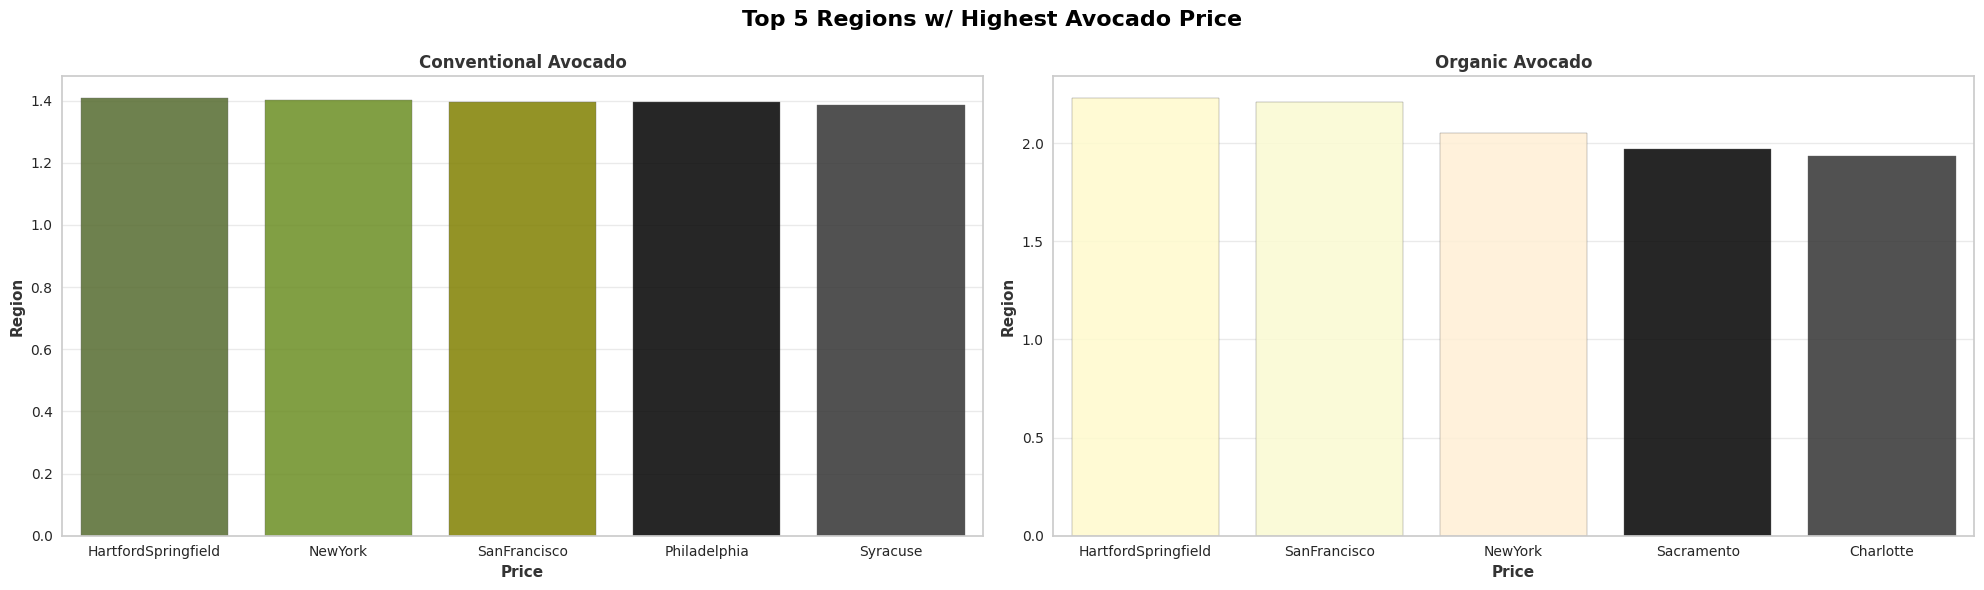

In [18]:
ds_conventional = ds[ds['type'] == 'conventional'][['region', 'AveragePrice']]
ds_organic = ds[ds['type'] == 'organic'][['region', 'AveragePrice']]

# 그룹화 + 평균 + 정렬
eda2 = ds_conventional.groupby('region').agg({'AveragePrice': 'mean'}).sort_values(by='AveragePrice', ascending=False).iloc[:5]
eda3 = ds_organic.groupby('region').agg({'AveragePrice': 'mean'}).sort_values(by='AveragePrice', ascending=False).iloc[:5]

# 색상 팔레트 정의 (예시)
black_grad = ['#000000', '#333333', '#666666']
olive_grad = ['#556B2F', '#6B8E23', '#808000']
yellow_grad = ['#FFFFE0', '#FFFACD', '#FAFAD2', '#FFEFD5']

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Top 5 Regions w/ Highest Avocado Price', fontweight='heavy', fontsize=16, fontfamily='sans-serif', color=black_grad[0])

# 왼쪽 그래프 - Conventional
plt.subplot(1, 2, 1)
plt.title('Conventional Avocado', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
bar_left = sns.barplot(y='AveragePrice', x=eda2.index, data=eda2, palette=black_grad, edgecolor=black_grad[2], alpha=0.85)
bar_left.patches[0].set_facecolor(olive_grad[0])
bar_left.patches[1].set_facecolor(olive_grad[1])
bar_left.patches[2].set_facecolor(olive_grad[2])
plt.xlabel('Price', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.ylabel('Region', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.grid(axis='y', alpha=0.4)
plt.grid(axis='x', alpha=0)
plt.ticklabel_format(style='plain', axis='y')

# 오른쪽 그래프 - Organic
plt.subplot(1, 2, 2)
plt.title('Organic Avocado', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
bar_right = sns.barplot(y='AveragePrice', x=eda3.index, data=eda3, palette=black_grad, edgecolor=black_grad[2], alpha=0.85)
bar_right.patches[0].set_facecolor(yellow_grad[1])
bar_right.patches[1].set_facecolor(yellow_grad[2])
bar_right.patches[2].set_facecolor(yellow_grad[3])
plt.xlabel('Price', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.ylabel('Region', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.grid(axis='y', alpha=0.4)
plt.grid(axis='x', alpha=0)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

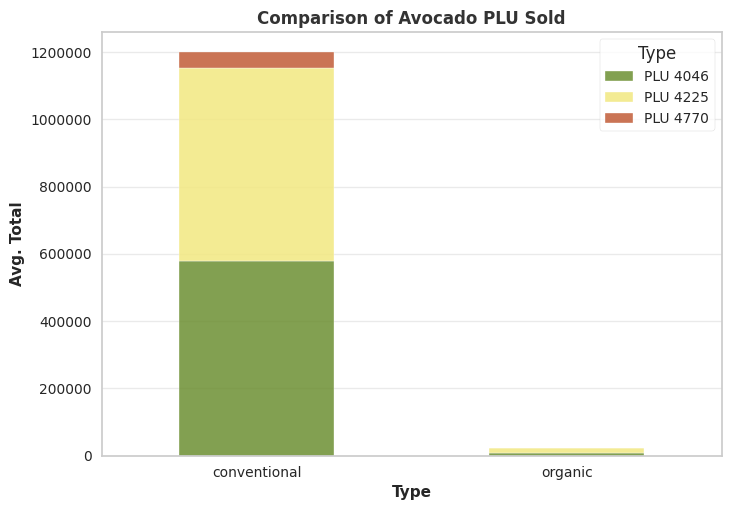

In [19]:
eda30 = ds[['type', '4046', '4225', '4770']]
eda30 = eda30.groupby('type').aggregate({
    '4046': np.mean,
    '4225': np.mean,
    '4770': np.mean
})

eda30.plot(kind='bar', stacked=True, color=color_mix[-4:-1], alpha=0.85)
plt.title('Comparison of Avocado PLU Sold', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
plt.xlabel('Type', fontweight='bold', fontsize=11, fontfamily='sans-serif')
plt.ylabel('Avg. Total', fontweight='bold', fontsize=11, fontfamily='sans-serif')
plt.grid(axis='y', alpha=0.4)
plt.grid(axis='x', alpha=0)
plt.legend(labels=['PLU 4046', 'PLU 4225', 'PLU 4770'], title='Type', loc='upper right', frameon=True)
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

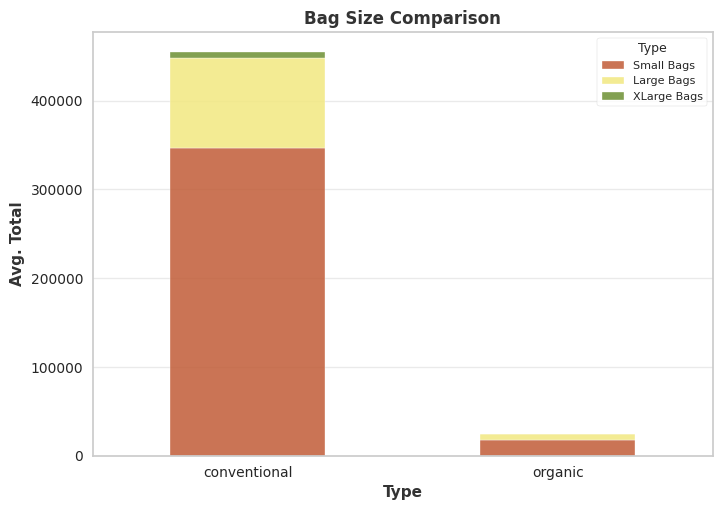

In [20]:
eda31 = ds[['type', 'Small Bags', 'Large Bags', 'XLarge Bags']]

eda31 = eda31.groupby('type').aggregate({
    'Small Bags': np.mean,
    'Large Bags': np.mean,
    'XLarge Bags': np.mean
})

eda31.plot(kind='bar', stacked=True, color=color_mix[3:0:-1], alpha=0.85)

plt.title('Bag Size Comparison', fontweight='bold', fontsize=12, fontfamily='sans-serif', color=black_grad[1])
plt.xlabel('Type', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.ylabel('Avg. Total', fontweight='bold', fontsize=11, fontfamily='sans-serif', color=black_grad[1])
plt.grid(axis='y', alpha=0.4)
plt.grid(axis='x', alpha=0)

plt.legend(
    labels=['Small Bags', 'Large Bags', 'XLarge Bags'],
    title='Type', fontsize=8, title_fontsize=9,
    loc='upper right', frameon=True
)

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


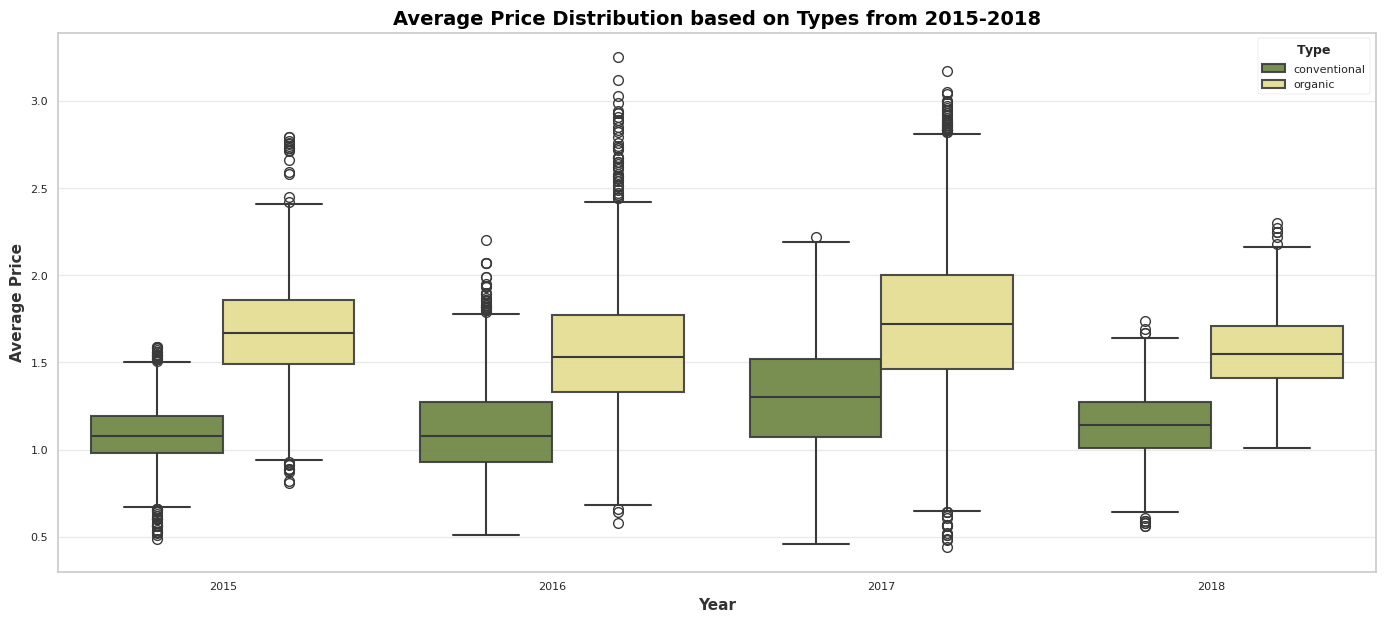

In [21]:
fig, ax = plt.subplots()
fig.set_size_inches(17, 7)
plt.title('Average Price Distribution based on Types from 2015-2018', fontweight='bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
sns.boxplot(x = 'year', y = 'AveragePrice', hue = 'type', data = ds, ax = ax, palette = color_mix[1:3],
            boxprops = dict(alpha = 0.9), linewidth = 1.5)
plt.xlabel('Year', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.legend(title = '$\\bf{Type}$', fontsize = 8, title_fontsize = 9, loc = 'upper right', frameon = True)
plt.grid(axis = 'y', alpha = 0.4)
plt.show()

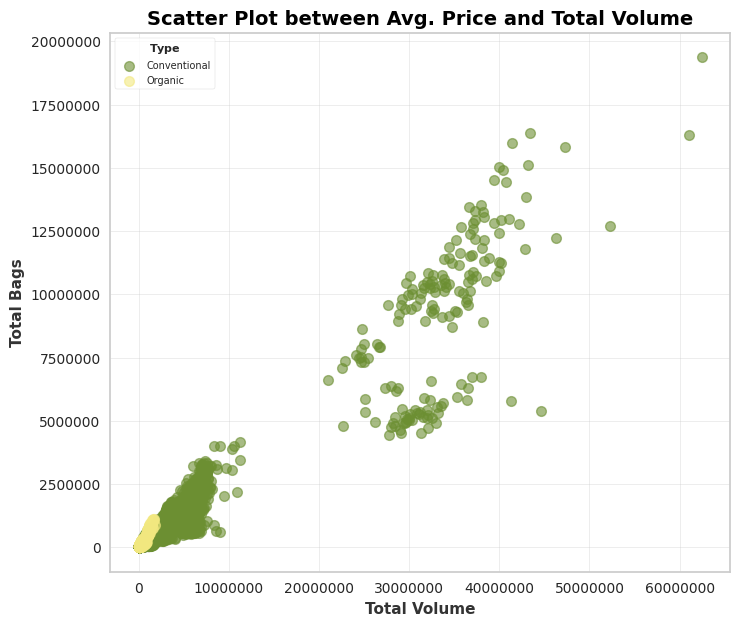

In [22]:
x0 = ds.xs('Total Volume', axis = 1)[ds.type == 'conventional']
x1 = ds.xs('Total Volume', axis = 1)[ds.type == 'organic']
y0 = ds.xs('Total Bags', axis = 1)[ds.type == 'conventional']
y1 = ds.xs('Total Bags', axis = 1)[ds.type == 'organic']

plt.figure(figsize = (8, 7))
plt.title('Scatter Plot between Avg. Price and Total Volume', fontweight = 'bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
plt.scatter(x = x0, y = y0, c = color_mix[1], alpha = 0.6, linewidths = 1)
plt.scatter(x = x1, y = y1, c = color_mix[2], alpha = 0.6, linewidths = 1)
plt.legend(['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8, loc = 'upper left',
           frameon = True)
plt.xlabel('Total Volume', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ylabel('Total Bags', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif', color = black_grad[1])
plt.ticklabel_format(style = 'plain', axis = 'both')
plt.grid(axis = 'both', alpha = 0.5, lw = 0.5)
plt.show()

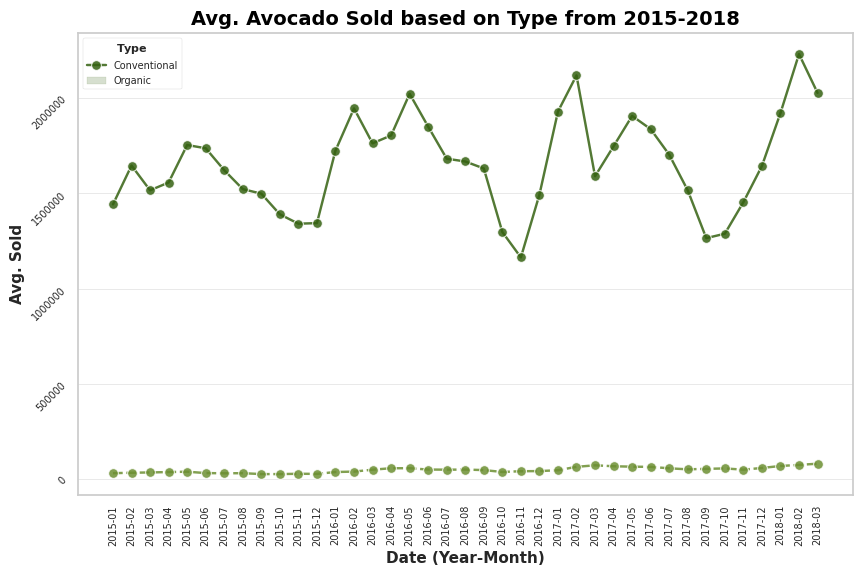

In [29]:
dseda8 = ds[['Date', 'Total Volume', 'type']]
dseda8['Date'] = pd.DatetimeIndex(dseda8['Date'])
dseda8['Date'] = dseda8['Date'].apply(lambda x: x.strftime('%Y-%m'))
group8 = dseda8.groupby(['Date', 'type'])
mnth_avg8 = group8.aggregate({'Total Volume': np.mean})

plt.figure(figsize = (10, 6))
plt.title('Avg. Avocado Sold based on Type from 2015-2018', fontweight = 'bold', fontsize = 14,
          fontfamily = 'sans-serif', color = black_grad[0])
sns.lineplot(data = mnth_avg8, x = 'Date', y = 'Total Volume', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = color_mix[0:2], alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Avg. Sold', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 90, fontsize = 7)
plt.yticks(rotation = 45, fontsize = 7)
plt.grid(axis='y', alpha = 0.5, lw = 0.6)
plt.grid(axis='x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8, frameon=True);

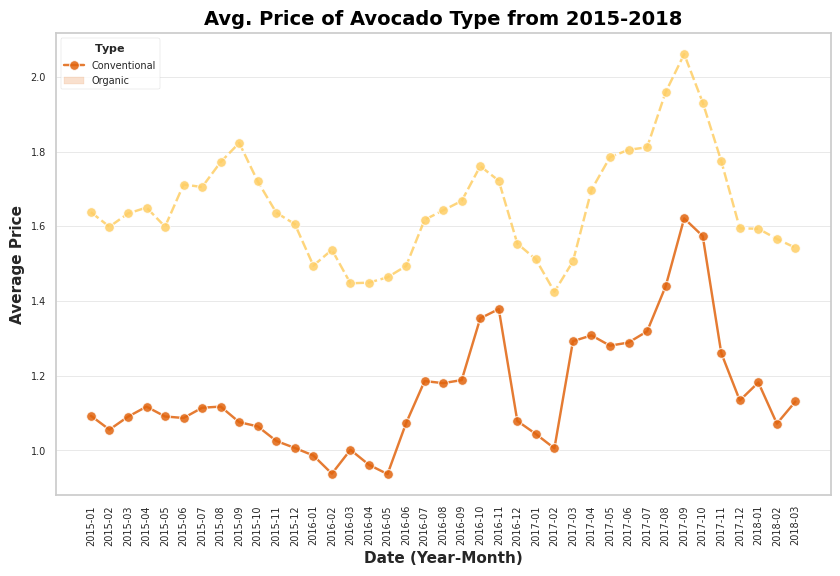

In [30]:
dseda9 = ds[['Date', 'AveragePrice', 'type']]
dseda9['Date'] = pd.DatetimeIndex(dseda9['Date'])
dseda9['Date'] = dseda9['Date'].apply(lambda x: x.strftime('%Y-%m'))
group9 = dseda9.groupby(['Date', 'type'])
mnth_avg9 = group9.aggregate({'AveragePrice': np.mean})

plt.figure(figsize = (10, 6))
plt.title('Avg. Price of Avocado Type from 2015-2018', fontweight = 'bold', fontsize = 14, fontfamily = 'sans-serif',
          color = black_grad[0])
sns.lineplot(data = mnth_avg9, x = 'Date', y = 'AveragePrice', hue = 'type', style = 'type', markers = ['o', 'o'],
             palette = 'YlOrBr_r', alpha = 0.85)
plt.xlabel('Date (Year-Month)', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ylabel('Average Price', fontweight = 'bold', fontsize = 11, fontfamily = 'sans-serif')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.xticks(rotation = 90, fontsize = 7)
plt.yticks(fontsize = 7)
plt.grid(axis = 'y', alpha = 0.5, lw = 0.6)
plt.grid(axis = 'x', alpha = 0)
plt.legend(labels = ['Conventional', 'Organic'], title = '$\\bf{Type}$', fontsize = 7, title_fontsize = 8,
           loc = 'upper left', frameon = True);

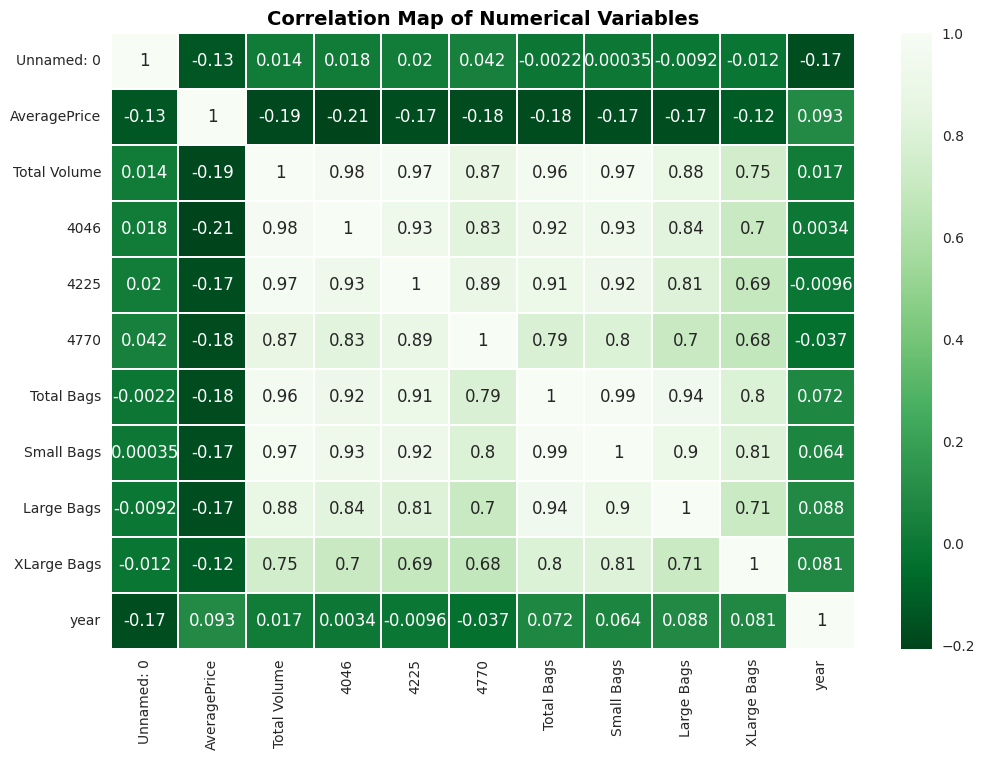

In [25]:
numeric_ds = ds.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_ds.corr(), annot=True, cmap='Greens_r', linewidths=0.1)

plt.title('Correlation Map of Numerical Variables', fontsize=14, fontweight='bold', fontfamily='sans-serif', color=black_grad[0])
plt.show()

In [26]:
ds.Date = pd.to_datetime(ds.Date)

ds['month'] = pd.DatetimeIndex(ds['Date']).month

In [27]:
import pycaret
print(pycaret.__version__)

3.3.2


In [28]:
pip install pycaret==2.3.10

  Using cached pycaret-2.3.10-py3-none-any.whl.metadata (12 kB)
  Using cached scipy-1.5.4.tar.gz (25.2 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [31]:
avc = setup(
    data=ds,
    target='AveragePrice',
    train_size=0.8,
    categorical_features=['type', 'year', 'region', 'month'],
    normalize=True,
    normalize_method='robust',
    session_id=123
)

,Description,Value
0,Session id,123
1,Target,AveragePrice
2,Target type,Regression
3,Original data shape,"(18249, 15)"
4,Transformed data shape,"(18249, 31)"
5,Transformed train set shape,"(14599, 31)"
6,Transformed test set shape,"(3650, 31)"
7,Numeric features,9
8,Date features,1
9,Categorical features,4


In [32]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [34]:
best_models = compare_models(sort='R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0739,0.0117,0.1081,0.9278,0.0434,0.0545,6.6600
rf,Random Forest Regressor,0.0801,0.0132,0.1146,0.9187,0.0460,0.0592,14.2520
xgboost,Extreme Gradient Boosting,0.0843,0.0135,0.1159,0.9168,0.0463,0.0615,0.6260
lightgbm,Light Gradient Boosting Machine,0.0986,0.0174,0.1320,0.8922,0.0535,0.0731,0.8850
dt,Decision Tree Regressor,0.1115,0.0284,0.1685,0.8241,0.0673,0.0813,0.6590
gbr,Gradient Boosting Regressor,0.1380,0.0341,0.1846,0.7894,0.0740,0.1024,4.7230
knn,K Neighbors Regressor,0.1563,0.0466,0.2158,0.7122,0.0862,0.1153,0.3120
ada,AdaBoost Regressor,0.1825,0.0523,0.2285,0.6771,0.0949,0.1443,1.8310
br,Bayesian Ridge,0.1823,0.0583,0.2413,0.6401,0.0975,0.1373,0.2190
ridge,Ridge Regression,0.1823,0.0583,0.2413,0.6401,0.0975,0.1373,0.2380


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

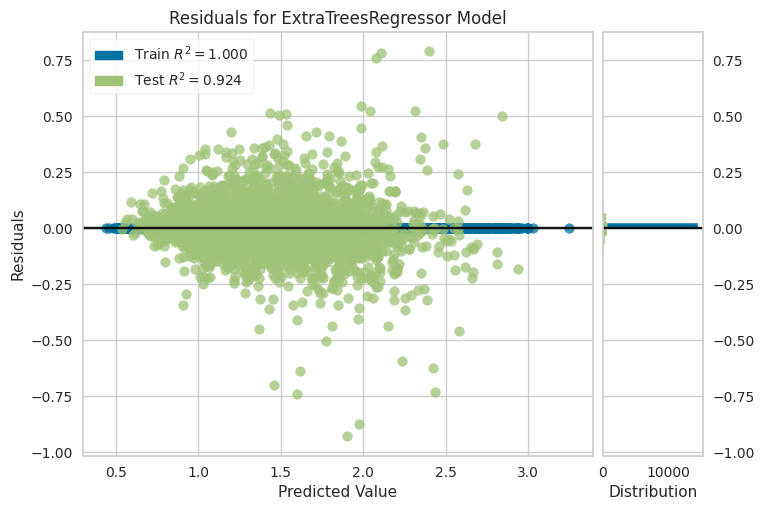

In [35]:
plot_model(best_models)

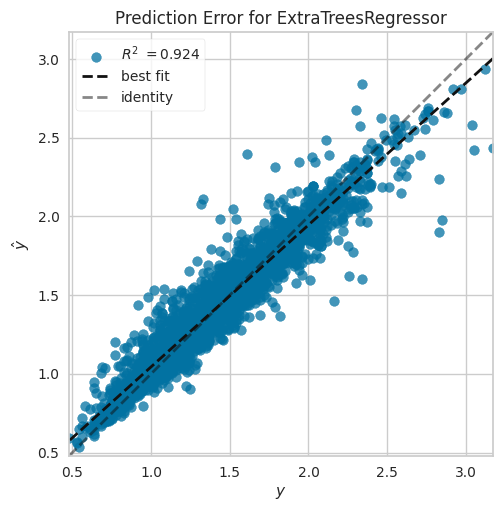

In [36]:
plot_model(best_models, plot = 'error')

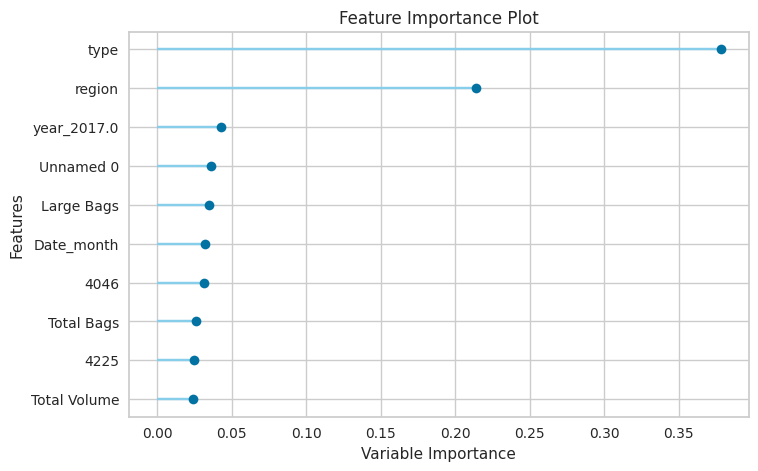

In [37]:
plot_model(best_models, plot = 'feature')

In [38]:
tuned_best = tune_model(
    best_models,
    n_iter=5,
    fold=3,
    optimize='R2'
)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,04:33:32
Status,. . . . . . . . . . . . . . . . . .,Finalizing Model
Estimator,. . . . . . . . . . . . . . . . . .,Extra Trees Regressor


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 5 candidates, totalling 15 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2402,0.0971,0.3116,0.4088,0.1253,0.1821
1,0.2357,0.0942,0.3069,0.4136,0.1245,0.1824
2,0.2366,0.0967,0.3110,0.4019,0.1251,0.1807
Mean,0.2375,0.0960,0.3098,0.4081,0.1250,0.1817
Std,0.0019,0.0013,0.0021,0.0048,0.0004,0.0008


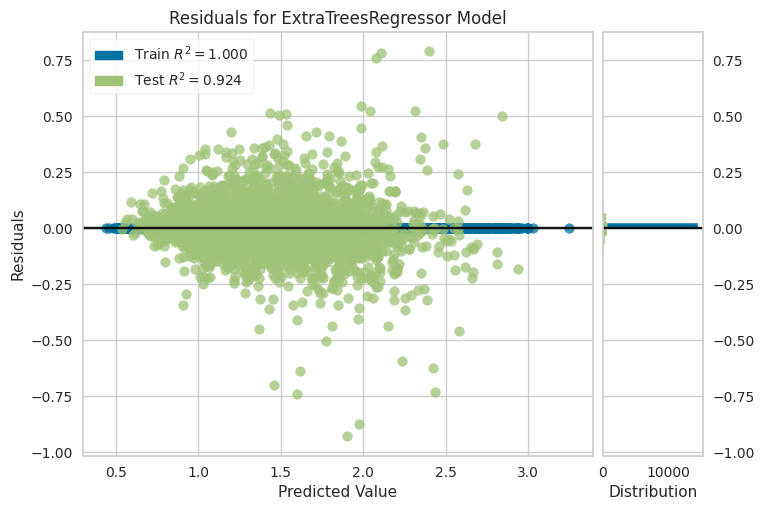

In [39]:
plot_model(tuned_best)

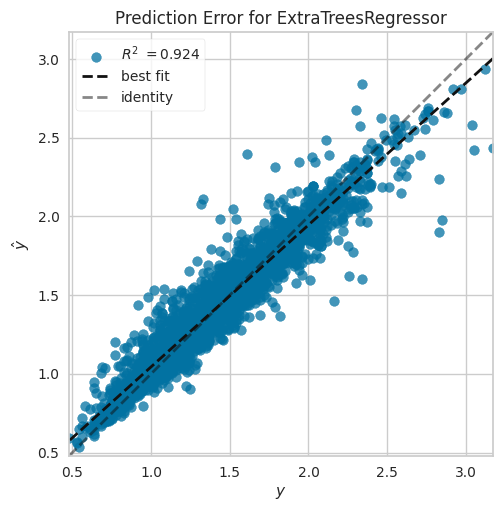

In [40]:
plot_model(tuned_best, plot = 'error')

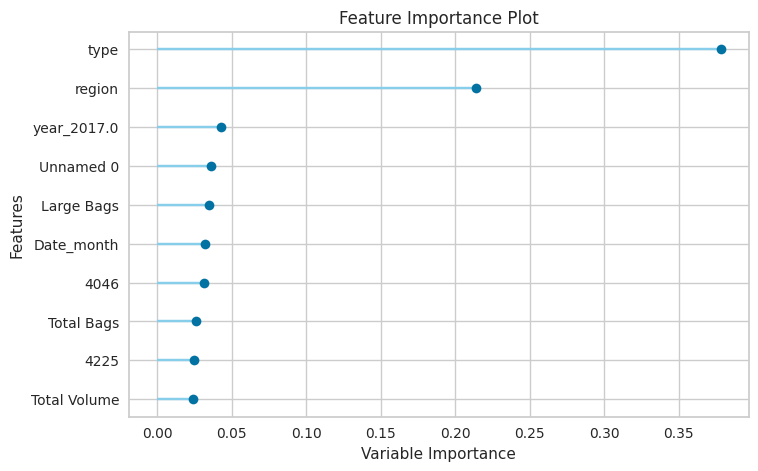

In [41]:
plot_model(tuned_best, plot = 'feature')

In [42]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0813,0.0140,0.1183,0.9164,0.0466,0.0591
1,0.0800,0.0120,0.1096,0.9304,0.0446,0.0587
2,0.0791,0.0127,0.1129,0.9155,0.0461,0.0594
3,0.0791,0.0135,0.1161,0.9180,0.0459,0.0578
4,0.0766,0.0114,0.1066,0.9306,0.0426,0.0563
5,0.0765,0.0123,0.1107,0.9191,0.0448,0.0571
6,0.0802,0.0137,0.1173,0.9142,0.0467,0.0589
7,0.0835,0.0147,0.1213,0.9133,0.0478,0.0608
8,0.0835,0.0137,0.1171,0.9131,0.0477,0.0624


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

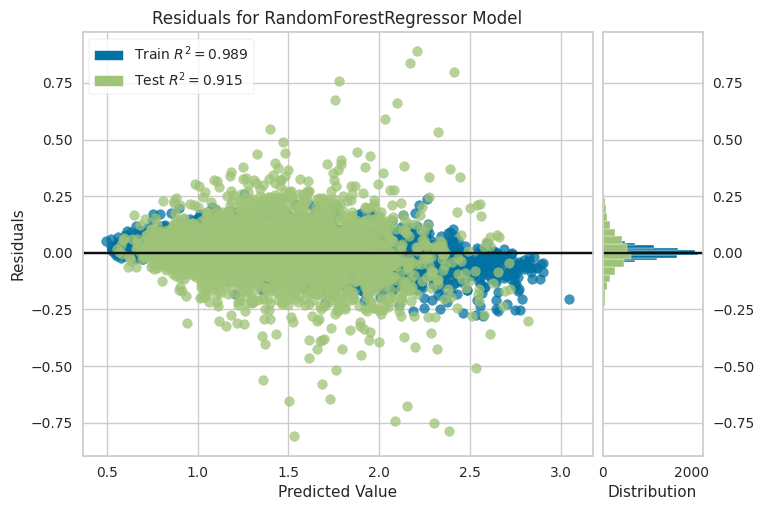

In [43]:
plot_model(rf)

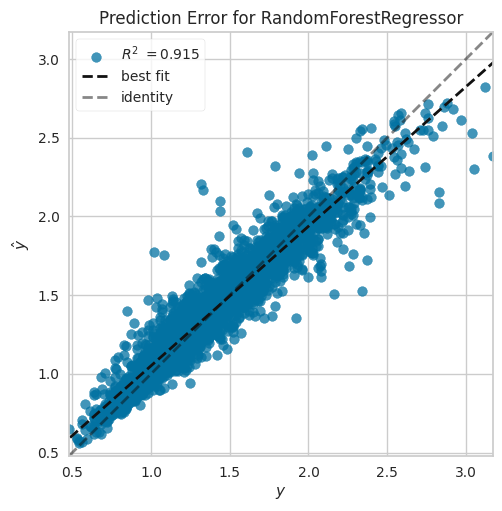

In [44]:
plot_model(rf, plot = 'error')

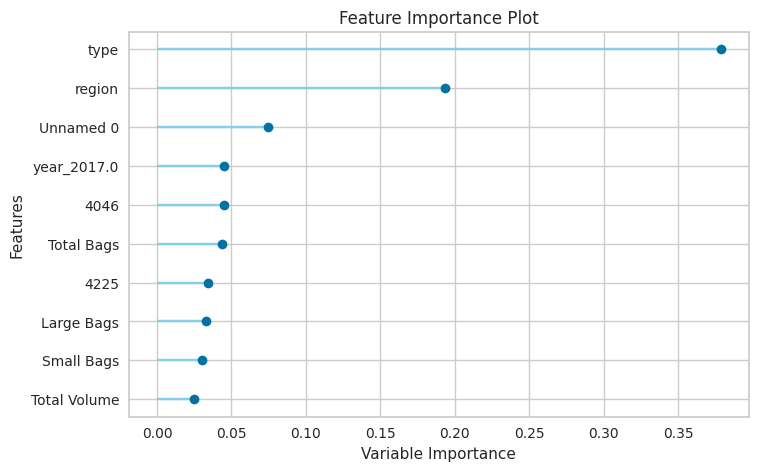

In [45]:
plot_model(rf, plot = 'feature')

In [52]:
tune_rf = tune_model(rf, n_iter=3, fold=3, optimize='R2')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2552,0.1056,0.3249,0.3573,0.1324,0.1980
1,0.2528,0.1042,0.3227,0.3515,0.1325,0.1997
2,0.2530,0.1063,0.3260,0.3425,0.1328,0.1973
Mean,0.2537,0.1053,0.3245,0.3504,0.1326,0.1983
Std,0.0011,0.0009,0.0014,0.0061,0.0002,0.0010


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 3 candidates, totalling 9 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


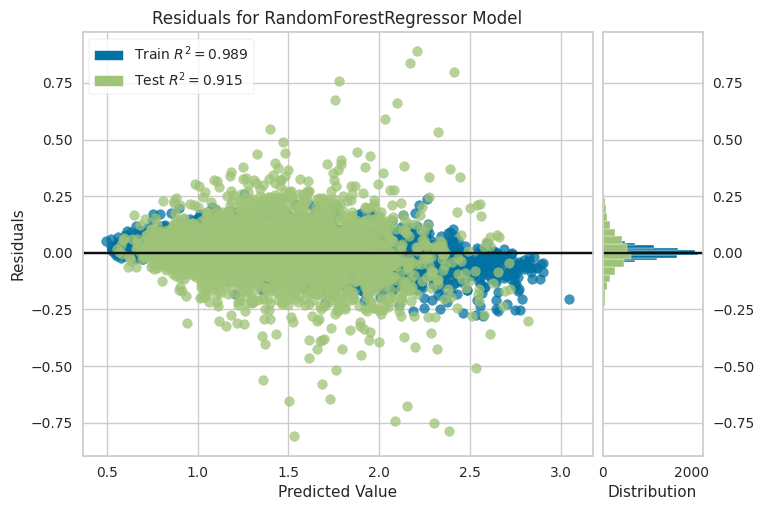

In [53]:
plot_model(tune_rf)

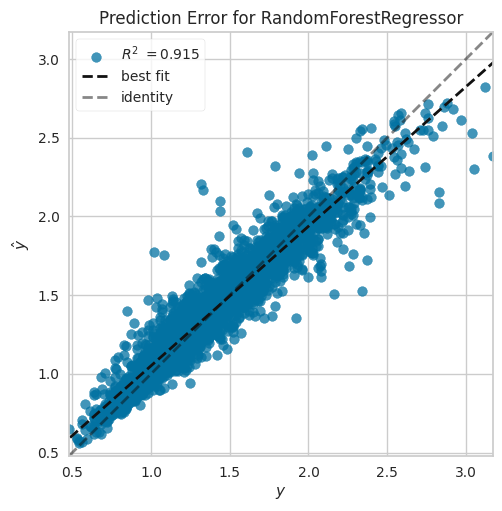

In [54]:
plot_model(tune_rf, plot = 'error')

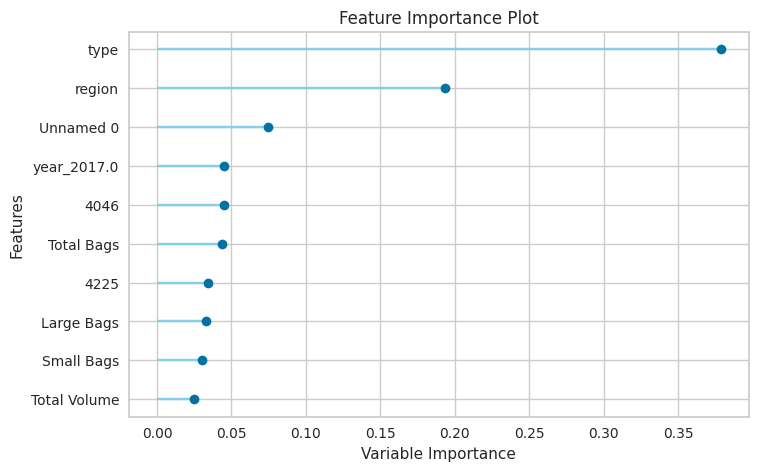

In [55]:
plot_model(tune_rf, plot = 'feature')

In [48]:
lgbm = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0988,0.0176,0.1327,0.8948,0.0528,0.0719
1,0.1005,0.0172,0.1310,0.9005,0.0531,0.0740
2,0.0990,0.0171,0.1309,0.8864,0.0542,0.0751
3,0.0943,0.0166,0.1287,0.8993,0.0516,0.0693
4,0.0936,0.0151,0.1229,0.9078,0.0495,0.0690
5,0.0966,0.0166,0.1289,0.8903,0.0526,0.0720
6,0.0989,0.0181,0.1345,0.8872,0.0541,0.0732
7,0.1024,0.0196,0.1399,0.8846,0.0557,0.0746
8,0.0994,0.0173,0.1315,0.8903,0.0541,0.0747


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

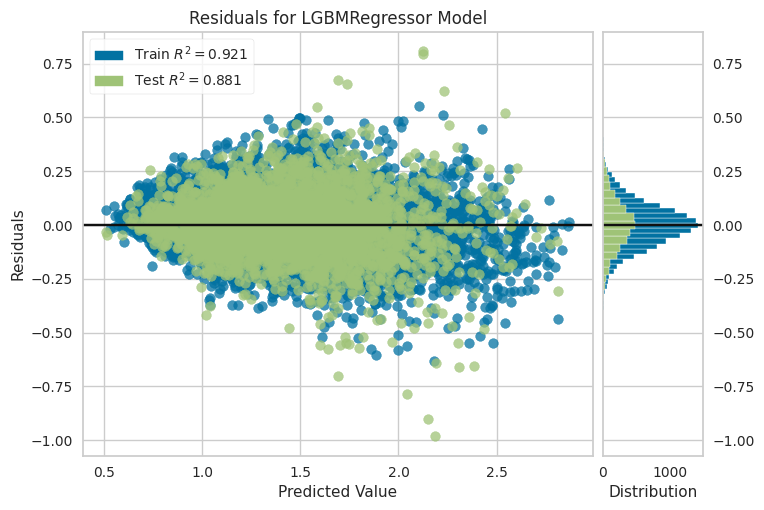

In [49]:
plot_model(lgbm)

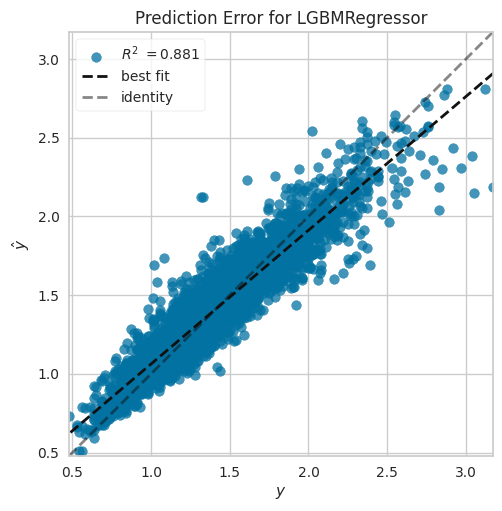

In [50]:
plot_model(lgbm, plot = 'error')

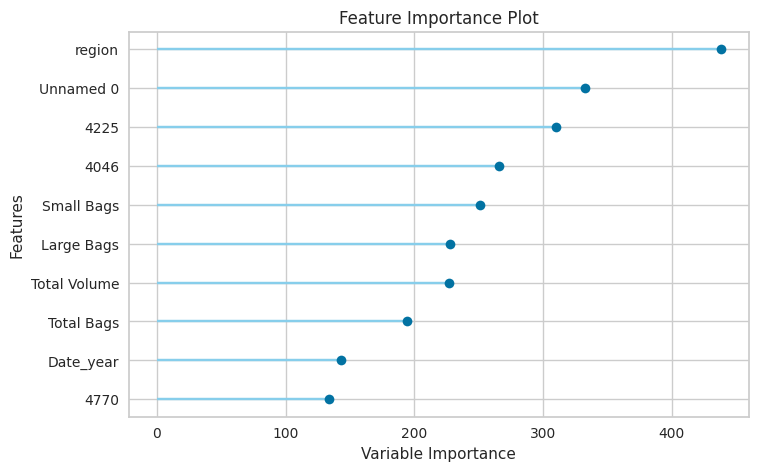

In [51]:
plot_model(lgbm, plot = 'feature')

In [56]:
tune_lgbm = tune_model(lgbm)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1149,0.0252,0.1588,0.8495,0.0627,0.0838
1,0.1186,0.0242,0.1555,0.8599,0.0627,0.0871
2,0.1170,0.0242,0.1555,0.8397,0.0643,0.0890
3,0.1107,0.0223,0.1494,0.8643,0.0599,0.0818
4,0.1117,0.0225,0.1500,0.8625,0.0601,0.0826
5,0.1106,0.0218,0.1476,0.8562,0.0604,0.0835
6,0.1181,0.0253,0.1591,0.8420,0.0643,0.0883
7,0.1203,0.0268,0.1637,0.8421,0.0651,0.0878
8,0.1219,0.0256,0.1601,0.8375,0.0648,0.0907


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


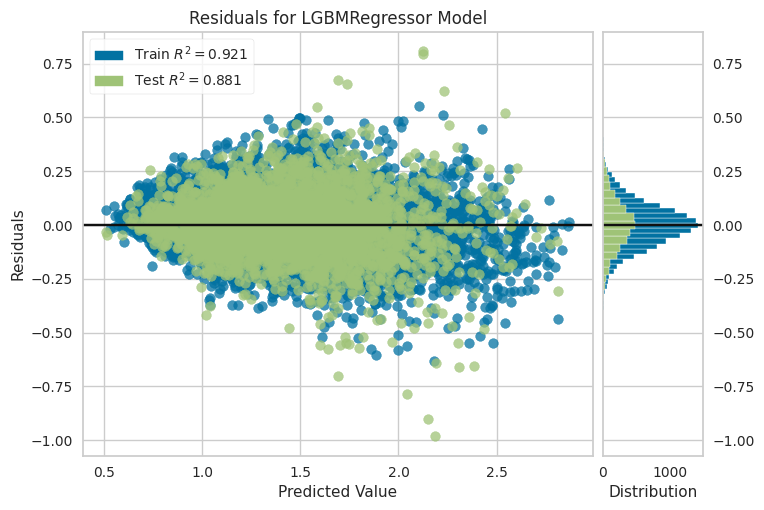

In [57]:
plot_model(tune_lgbm)

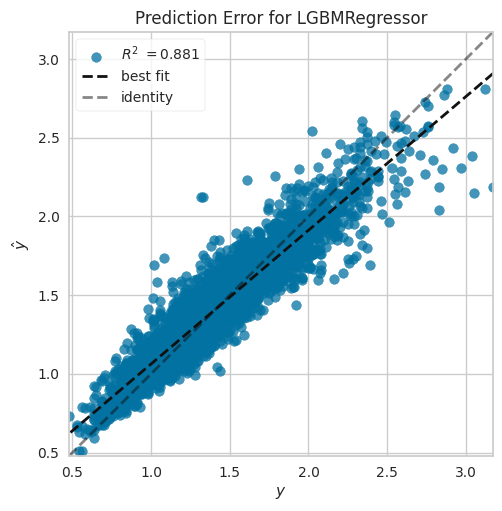

In [58]:
plot_model(tune_lgbm, plot = 'error')

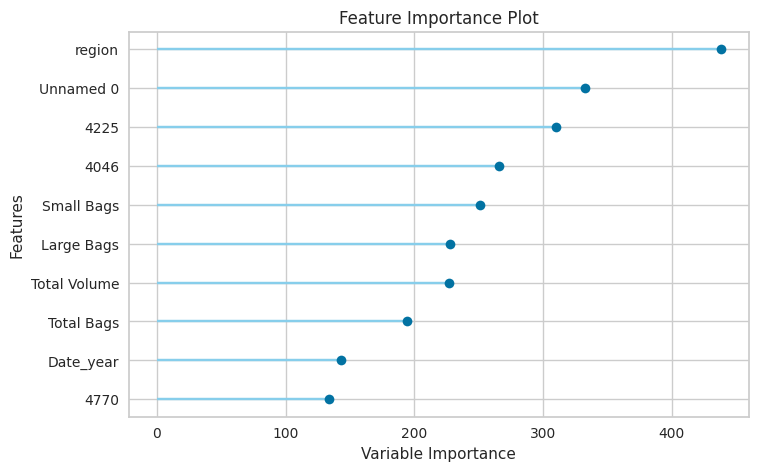

In [59]:
plot_model(tune_lgbm, plot = 'feature')

In [60]:
predict_model(best_models)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0734,0.0122,0.1106,0.9244,0.0440,0.0540


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8442
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.6179
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.5701
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0194
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.4351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9325
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.1133
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.0826
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.2988


In [61]:
predict_model(rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0798,0.0137,0.1172,0.9151,0.0466,0.0586


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8497
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.6042
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.5587
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0627
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.2473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9434
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.0893
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.1905
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.3179


In [62]:
predict_model(lgbm)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.1018,0.0192,0.1387,0.8811,0.0552,0.0746


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.857325
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.562000
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.477120
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.057732
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.232317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.949554
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.059290
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,1.124681
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.481890


In [63]:
final_best = finalize_model(best_models)

plot_model(best_models, plot='parameter')

,Parameters
bootstrap,False
ccp_alpha,0.0
criterion,squared_error
max_depth,None
max_features,1.0
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1
min_samples_split,2


In [64]:
predict_model(final_best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.2360,0.1352,0.3677,0.1647,0.1445,0.1401


,Unnamed: 0,Date,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,AveragePrice,prediction_label
5078,34,2016-05-01,8.580374e+05,9.113613e+04,2.710051e+05,11463.750000,484432.531250,458041.093750,25900.730469,490.709991,conventional,2016,Seattle,5,0.82,0.8678
10697,11,2015-10-11,8.749600e+03,6.000000e+00,6.835000e+01,0.000000,8675.250000,8675.250000,0.000000,0.000000,organic,2015,NorthernNewEngland,10,1.61,1.1755
15569,33,2017-05-14,1.437912e+05,3.379520e+03,7.303243e+04,0.000000,67379.257812,29130.710938,38248.550781,0.000000,organic,2017,GreatLakes,5,1.68,1.1483
2001,25,2015-07-05,2.875719e+05,9.488031e+04,1.180226e+05,15212.240234,59456.820312,58905.710938,551.109985,0.000000,conventional,2015,RichmondNorfolk,7,1.01,1.0165
15780,32,2017-05-21,8.759490e+03,7.682000e+01,1.259860e+03,0.000000,7422.810059,2038.260010,5384.549805,0.000000,organic,2017,Indianapolis,5,0.92,1.2662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,51,2016-01-03,4.065584e+06,6.046972e+05,2.200075e+06,543717.875000,717093.500000,438279.968750,147920.687500,130892.796875,conventional,2016,GreatLakes,1,0.92,0.9092
326,14,2015-09-20,4.759791e+06,1.702966e+06,2.230694e+06,273922.375000,552209.750000,529779.375000,17303.910156,5126.490234,conventional,2015,California,9,1.14,1.1134
17177,51,2017-01-08,1.044249e+05,2.621250e+04,6.181320e+03,0.000000,72031.062500,69782.273438,2248.790039,0.000000,organic,2017,SouthCentral,1,1.10,0.8160
13098,21,2016-07-31,1.153139e+05,1.465426e+04,2.827826e+04,1.600000,72379.726562,70166.726562,2213.000000,0.000000,organic,2016,LosAngeles,7,1.21,1.1026


In [65]:
save_model(final_best,'Final_Best_Model_caesarmario_06May2022')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('date_feature_extractor',
                  TransformerWrapper(include=['Date'],
                                     transformer=ExtractDateTimeFeatures())),
                 ('numerical_imputer',
                  TransformerWrapper(include=['Unnamed: 0', 'Total Volume',
                                              '4046', '4225', '4770',
                                              'Total Bags', 'Small Bags',
                                              'Large Bags', 'XLarge Bags'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  Tran...
                                                               use_cat_names=True))),
                 ('rest_encoding',
                  TransformerWrapper(include=['region'],
                                     transformer=TargetEncoder(cols=['region'],
                                                       